# Yield Model Calculator for D2W hybrid bonding
#### Author: Zhichao Chen
#### Date: Aug 25, 2025
#### Description: YAP+ (pad-layout-aware yield analysis)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from utils.util import *
import time
import os
import matplotlib.pyplot as plt
from assembly_yield_calculator import Pad_Yield_Map_Generator

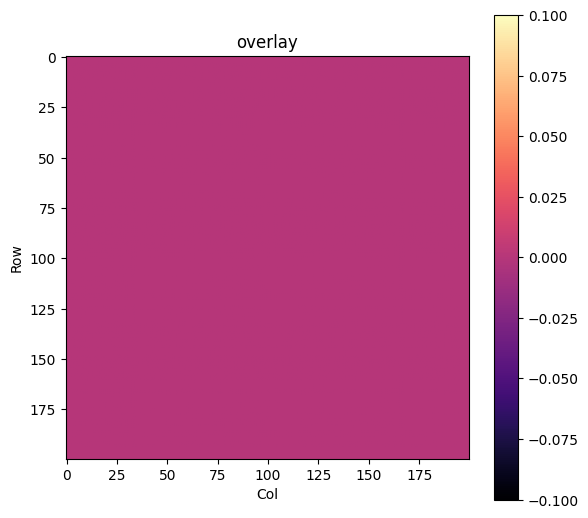

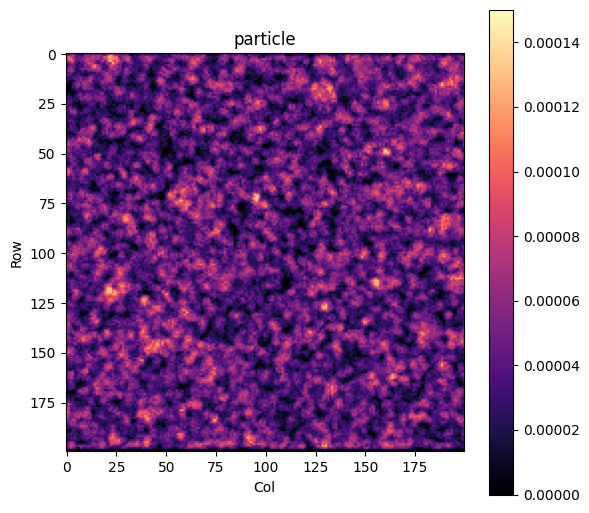

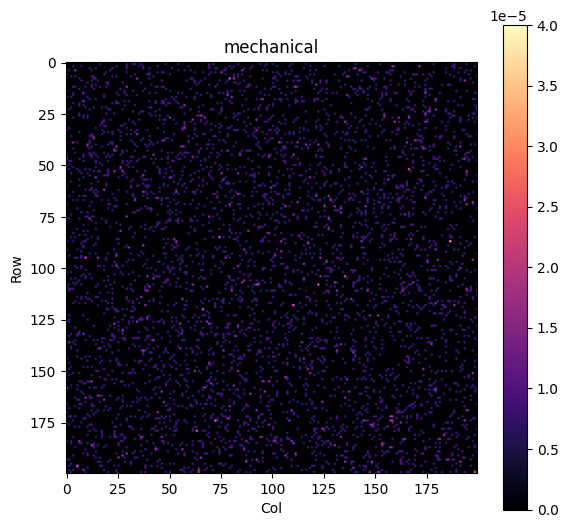

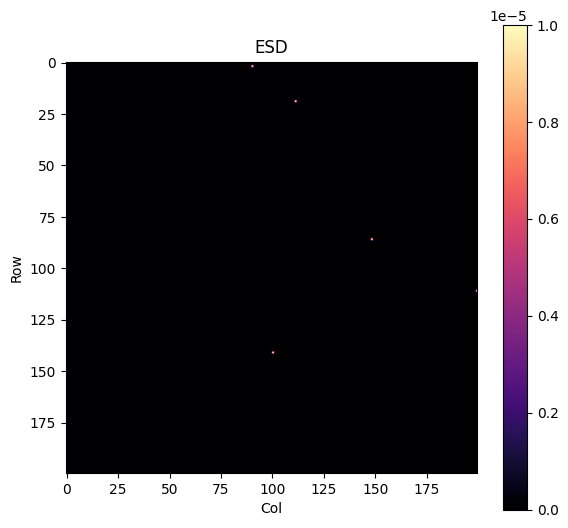

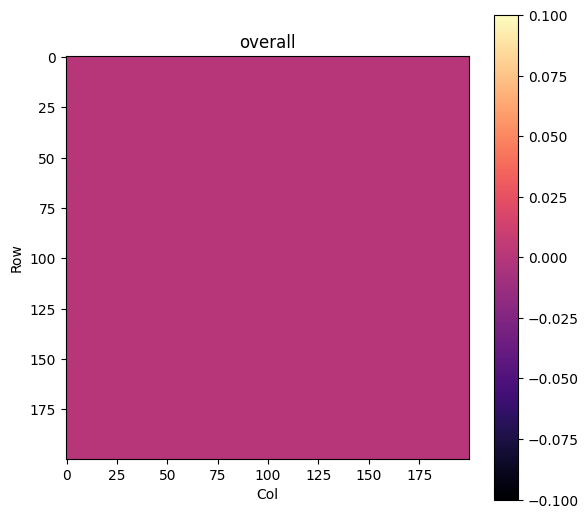

In [4]:
import numpy as np
import matplotlib.pyplot as plt

npz_path = r"output/random_10x10_50/assembly_fail_map_dict.npz"

data = np.load(npz_path)

# Optional: control colormap and value range
cmap = "magma"  # or "viridis"
vmin = 0.0
vmax = None  # set a float if you want consistent scaling

for key in data.files:
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(data[key], origin="upper", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(key)
    ax.set_xlabel("Col")
    ax.set_ylabel("Row")
    plt.colorbar(im, ax=ax, shrink=0.85)
    plt.tight_layout()
    plt.show()


In [ ]:
# Load configuration
cfg = load_modeling_config(path='configs/HBM_footprint_A_config.yaml', 
                     mode='d2w_modeling',
                     debug=False)
# If the directory does not exist, create it
if not os.path.exists(cfg.OUTPUT_DIR + cfg.INTERFACE):
    os.makedirs(cfg.OUTPUT_DIR + cfg.INTERFACE)

update_config_items(cfg=cfg, mode='d2w_modeling')

pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
                            # blox_bmap_path=cfg.INPUT_DIR + cfg.INTERFACE + '.bmap',
                            blox_bmap_path=cfg.INPUT_DIR + 'HBM_footprint_A_3d_output.bmap',
                            criticality_path=cfg.INPUT_DIR + 'HBM_footprint_A_3d_criticality.txt',
                            pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN)


# Calculate the yield
start_time = time.time()
pad_yield_map = Pad_Yield_Map_Generator(
    cfg=cfg, 
    pad_bitmap_collection=pad_bitmap_collection,
)

In [ ]:
warp_300nm_dict = np.load("peeling_stress_300warp.npz", allow_pickle=True)
warp_200nm_dict = np.load("peeling_stress_200warp.npz", allow_pickle=True)
warp_100nm_dict = np.load("peeling_stress_100warp.npz", allow_pickle=True)

plt.figure(figsize=(4, 3), dpi=300)
plt.scatter(warp_300nm_dict['r_m'][-80:] * 1e3, 
            warp_300nm_dict['p_pa'][-80:] / 1e6, label=r'300 nm $\Delta W_0$', alpha=0.6, s=10)
plt.scatter(warp_200nm_dict['r_m'][-80:] * 1e3, 
            warp_200nm_dict['p_pa'][-80:] / 1e6, label=r'200 nm $\Delta W_0$', alpha=0.6, s=10)
plt.scatter(warp_100nm_dict['r_m'][-80:] * 1e3, 
            warp_100nm_dict['p_pa'][-80:] / 1e6, label=r'100 nm $\Delta W_0$', alpha=0.6, s=10)
plt.xlabel('Distance from Center (mm)', fontsize=12)
plt.ylabel('Peeling Stress (Pa)', fontsize=12)
plt.title(r'$\sigma_g(a)$ vs. $a$ for various $\Delta W_0$', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

In [ ]:
mech_yield_dist_dict_100warp_1dish = np.load(cfg.OUTPUT_DIR + cfg.INTERFACE + '/' + cfg.INTERFACE + "_cu_expansion_yield_vs_distance_100warp_1dish.npz",)
mech_yield_dist_dict_200warp_1dish = np.load(cfg.OUTPUT_DIR + cfg.INTERFACE + '/' + cfg.INTERFACE + "_cu_expansion_yield_vs_distance_200warp_1dish.npz",)
mech_yield_dist_dict_300warp_1dish = np.load(cfg.OUTPUT_DIR + cfg.INTERFACE + '/' + cfg.INTERFACE + "_cu_expansion_yield_vs_distance_300warp_1dish.npz",)
mech_yield_dist_dict_100warp_0d5dish = np.load(cfg.OUTPUT_DIR + cfg.INTERFACE + '/' + cfg.INTERFACE + "_cu_expansion_yield_vs_distance_100warp_0d5dish.npz",)
mech_yield_dist_dict_200warp_0d5dish = np.load(cfg.OUTPUT_DIR + cfg.INTERFACE + '/' + cfg.INTERFACE + "_cu_expansion_yield_vs_distance_200warp_0d5dish.npz",)
mech_yield_dist_dict_300warp_0d5dish = np.load(cfg.OUTPUT_DIR + cfg.INTERFACE + '/' + cfg.INTERFACE + "_cu_expansion_yield_vs_distance_300warp_0d5dish.npz",)
plt.figure(figsize=(4, 3), dpi=300)
num_dots = 3
# plt.plot(mech_yield_dist_dict_100warp_1dish['pad_distances_um'][-num_dots:], 
#          mech_yield_dist_dict_100warp_1dish['pad_yields'][-num_dots:], label=r'$\Delta W$ = 100 nm & d = 1.0 nm', alpha=0.8)
plt.plot(mech_yield_dist_dict_200warp_1dish['pad_distances_um'][-num_dots:],
            mech_yield_dist_dict_200warp_1dish['pad_yields'][-num_dots:], label=r'$\Delta W$ = 200 nm & d = 1.0 nm', alpha=0.8)
plt.plot(mech_yield_dist_dict_300warp_1dish['pad_distances_um'][-num_dots:],
            mech_yield_dist_dict_300warp_1dish['pad_yields'][-num_dots:], label=r'$\Delta W$ = 300 nm & d = 1.0 nm', alpha=0.8)
# plt.plot(mech_yield_dist_dict_100warp_0d5dish['pad_distances_um'][-num_dots:],
#             mech_yield_dist_dict_100warp_0d5dish['pad_yields'][-num_dots:], '--', label=r'$\Delta W$ = 100 nm & d = 0.5 nm', alpha=0.8)
plt.plot(mech_yield_dist_dict_200warp_0d5dish['pad_distances_um'][-num_dots:],
            mech_yield_dist_dict_200warp_0d5dish['pad_yields'][-num_dots:], '--', label=r'$\Delta W$ = 200 nm & d = 0.5 nm', alpha=0.8)
plt.plot(mech_yield_dist_dict_300warp_0d5dish['pad_distances_um'][-num_dots:],
            mech_yield_dist_dict_300warp_0d5dish['pad_yields'][-num_dots:], '--', label=r'$\Delta W$ = 300 nm & d = 0.5 nm', alpha=0.8)
plt.xlabel('Distance from Center (um)', fontsize=12)
plt.ylabel('Pad Yield', fontsize=12)
# Constraint Y axis to [0, 1]
plt.xlim(6850, 6880)
plt.ylim(0.9, 1.01)
plt.title('Pad Yield vs. Distance from Center', fontsize=12)
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

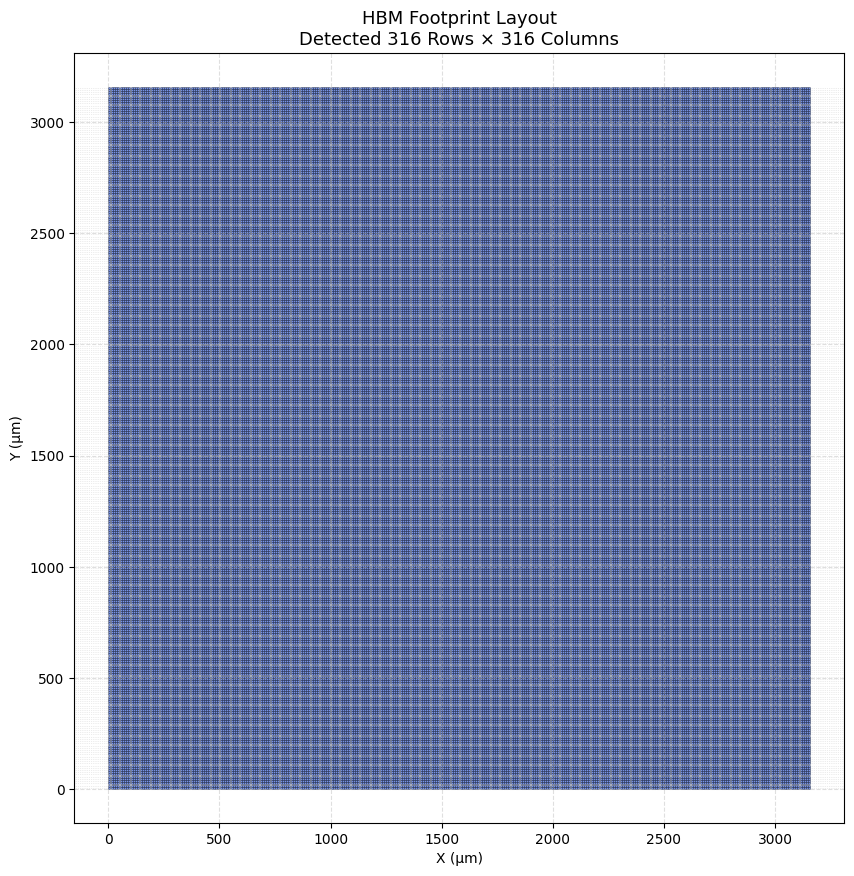

📊 检测到：316 行 × 316 列
X 范围: 5.0 ~ 3155.0
Y 范围: 5.0 ~ 3155.0


(316, 316)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_bmap_layout(bmap_path, y_tol=5.0, x_tol=5.0):
    """
    绘制 HBM pad 的几何布局，并估算行列数。
    """
    coords = []

    with open(bmap_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            try:
                x, y = float(parts[2]), float(parts[3])
                coords.append((x, y))
            except ValueError:
                continue

    if not coords:
        print("❌ 没有找到有效坐标数据。")
        return

    coords = np.array(coords)

    # 按 y 从大到小排列
    coords = coords[np.argsort(-coords[:, 1])]

    # 聚类得到唯一行
    y_vals = []
    for y in coords[:, 1]:
        if not y_vals or abs(y - y_vals[-1]) > y_tol:
            y_vals.append(y)
    num_rows = len(y_vals)

    # 聚类得到第一行的唯一列
    first_row_y = y_vals[0]
    first_row = coords[np.abs(coords[:, 1] - first_row_y) < y_tol]
    x_vals = []
    for x in sorted(first_row[:, 0]):
        if not x_vals or abs(x - x_vals[-1]) > x_tol:
            x_vals.append(x)
    num_cols = len(x_vals)

    # 绘制
    plt.figure(figsize=(10, 10))
    plt.scatter(coords[:, 0], coords[:, 1], s=3, c='royalblue', alpha=0.7, edgecolors='k', linewidths=0.3)
    plt.title(f"HBM Footprint Layout\nDetected {num_rows} Rows × {num_cols} Columns", fontsize=13)
    plt.xlabel("X (μm)")
    plt.ylabel("Y (μm)")
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle='--', alpha=0.4)

    # 可选：标出每行的中心线
    for y in y_vals:
        plt.axhline(y, color='gray', linestyle=':', linewidth=0.5, alpha=0.3)

    plt.show()

    print(f"📊 检测到：{num_rows} 行 × {num_cols} 列")
    print(f"X 范围: {coords[:,0].min():.1f} ~ {coords[:,0].max():.1f}")
    print(f"Y 范围: {coords[:,1].min():.1f} ~ {coords[:,1].max():.1f}")

    return num_rows, num_cols

plot_bmap_layout('input/interposer_To_CPU.bmap', y_tol=0.1, x_tol=0.1)
